### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import os
import string
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from nltk.tokenize import RegexpTokenizer
from nltk import PorterStemmer, WordNetLemmatizer
import pickle
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

In [2]:
data = pd.read_csv('data/raw/cyberbullying_tweets.csv')

#### Encoding the *classification_type* values.

In [3]:
labelencoder = LabelEncoder()
data['cyberbullying_type_encoded'] = labelencoder.fit_transform(data['cyberbullying_type'])
data[['cyberbullying_type', 'cyberbullying_type_encoded']].value_counts()

cyberbullying_type   cyberbullying_type_encoded
religion             5                             7998
age                  0                             7992
gender               2                             7973
ethnicity            1                             7961
not_cyberbullying    3                             7945
other_cyberbullying  4                             7823
dtype: int64

#### Preprocessing

In [5]:
# preprocessing functions


def text_lower(text):
    return text.str.lower()


def clean_stopwords(text):
    
    stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're',
             's', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves']
    STOPWORDS = set(stopwordlist)
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])


def clean_puctuations(text):
    english_puctuations = string.punctuation
    translator = str.maketrans('','', english_puctuations)
    return text.translate(translator)


def clean_repeating_characters(text):
    return re.sub(r'(.)1+', r'1', text)


def clean_URLs(text):
    return re.sub(r"((www.[^s]+)|(http\S+))","",text)


def clean_numeric(text):
    return re.sub('[0-9]+', '', text)


def tokenize_tweet(text):
    tokenizer = RegexpTokenizer('\w+')
    text = text.apply(tokenizer.tokenize)
    return text


def text_stemming(text):
    st = PorterStemmer()
    text = [st.stem(word) for word in text]
    return text


def text_lemmatization(text):
    lm = WordNetLemmatizer()
    text = [lm.lemmatize(word) for word in text]
    return text

In [6]:
# defining preprocess function

def preprocess(text):
    text = text_lower(text)
    text = text.apply(lambda text: clean_stopwords(text))
    text = text.apply(lambda x : clean_puctuations(x))
    text = text.apply(lambda x: clean_repeating_characters(x))
    text = text.apply(lambda x : clean_URLs(x))
    text = text.apply(lambda x: clean_numeric(x))
    text = tokenize_tweet(text)
    text = text.apply(lambda x: text_stemming(x))
    text = text.apply(lambda x: text_lemmatization(x))
    text = text.apply(lambda x : " ".join(x))
    return text

data['tweet_text'] = preprocess(data['tweet_text'])
data

,tweet_text,cyberbullying_type,cyberbullying_type_encoded
0,word katandandr food crapilici mkr,not_cyberbullying,3
1,aussietv white mkr theblock imacelebrityau tod...,not_cyberbullying,3
2,xochitlsuckkk classi whore red velvet cupcak,not_cyberbullying,3
3,jasongio meh p thank head up but not concern a...,not_cyberbullying,3
4,rudhoeenglish isi account pretend kurdish acco...,not_cyberbullying,3
...,...,...,...
47687,black ppl arent expect anyth depend anyth yet ...,ethnicity,1
47688,turner not withhold disappoint turner call cou...,ethnicity,1
47689,swear god dumb nigger bitch got bleach hair re...,ethnicity,1
47690,yea fuck rt therealexel nigger fuck unfollow m...,ethnicity,1


#### Model Creation

In [8]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Cyberbullying_Detection")

2025/05/24 18:32:43 INFO mlflow.tracking.fluent: Experiment with name 'Cyberbullying_Detection' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/845128051979318176', creation_time=1748091763470, experiment_id='845128051979318176', last_update_time=1748091763470, lifecycle_stage='active', name='Cyberbullying_Detection', tags={}>

In [9]:
X, y = data['tweet_text'], data['cyberbullying_type_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 41)

In [10]:
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features= 500000)
vectoriser.fit(X_train)

TfidfVectorizer(max_features=500000, ngram_range=(1, 2))

In [11]:
# Dumping the vectoriser
pickle.dump(vectoriser, open('tdf_vectorizer', 'wb'))

In [12]:
X_train = vectoriser.transform(X_train)
X_test = vectoriser.transform(X_test)

In [13]:
# Model
svm_model_linear = SVC(kernel= 'linear', C = 1).fit(X_train, y_train)
svm_predictions  = svm_model_linear.predict(X_test)
accuracy = svm_model_linear.score(X_test, y_test)
print(accuracy)

0.8290466871680179


In [14]:
# dumping the model
pickle.dump(svm_model_linear, open('model.bin', 'wb'))

2025/05/24 18:39:37 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - pandas (current: 1.4.3, required: pandas==1.5.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2025/05/24 18:39:37 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - pandas (current: 1.4.3, required: pandas==1.5.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
/home/hymavathi/.local/lib/python3.10/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
2025/05/24 18:39:37 WARNING mlflow.models.model: Failed to 

✅ Model training complete and logged to MLflow!
🏃 View run whimsical-croc-991 at: http://localhost:5000/#/experiments/845128051979318176/runs/8f297147a96846a582b622fe89307eba
🧪 View experiment at: http://localhost:5000/#/experiments/845128051979318176


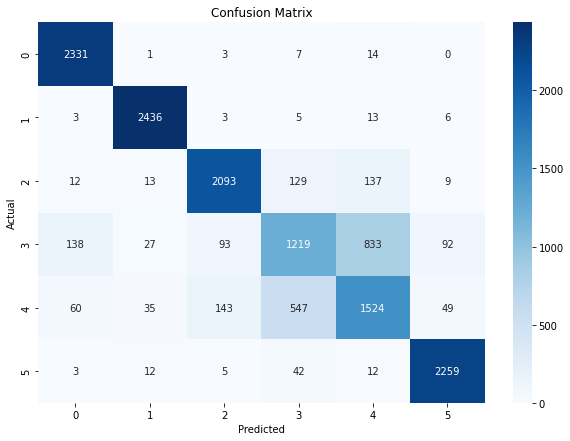

In [ ]:

# MLflow Logging
with mlflow.start_run():
    mlflow.set_tags({"developer": "hymavathi", "project": "cyberbullying-detection"})

    # Log parameters
    mlflow.log_params({
        "model_type": "SVC(linear)",
        "ngram_range": "(1,2)",
        "max_features": 500000,
        "C": 1,
        "kernel": "linear"
    })

    # Metrics
    report = classification_report(y_test, svm_predictions, output_dict=True)
    cm = confusion_matrix(y_test, svm_predictions)
    mlflow.log_metric("accuracy", accuracy)

    for label in report:
        if label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        mlflow.log_metrics({
            f"precision_{label}": report[label]['precision'],
            f"recall_{label}": report[label]['recall'],
            f"f1_{label}": report[label]['f1-score']
        })

    
    example_text = "This is a sample tweet for testing."
    input_example = pd.DataFrame({"tweet_text": [example_text]})
    vectorized_input = vectoriser.transform(input_example["tweet_text"])
    prediction_output = svm_model_linear.predict(vectorized_input)
    signature = infer_signature(input_example, prediction_output)

    # Log model
    mlflow.sklearn.log_model(
        svm_model_linear, "model",
        signature=signature,
        input_example=input_example,
        pip_requirements=[
            "scikit-learn==1.1.2", "cloudpickle==3.1.1", "pandas==1.5.3"
        ]
    )

    # Log confusion matrix plot
    os.makedirs("artifacts", exist_ok=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig("artifacts/confusion_matrix.png")
    mlflow.log_artifact("artifacts/confusion_matrix.png")

    # Log classification report
    pd.DataFrame(report).transpose().to_csv("artifacts/classification_report.csv")
    mlflow.log_artifact("artifacts/classification_report.csv")

    # Log top features if coefficients are available
    feature_names = vectoriser.get_feature_names_out()
    coef = svm_model_linear.coef_.toarray() if hasattr(svm_model_linear, "coef_") else None
    top_features_df = pd.DataFrame()

    if coef is not None:
        for i, class_label in enumerate(svm_model_linear.classes_):
            class_coef = coef[i]
            top_indices = np.argsort(class_coef)[::-1][:10]
            top_words = [feature_names[j] for j in top_indices]
            top_scores = [class_coef[j] for j in top_indices]
            top_features_df = pd.concat([
                top_features_df,
                pd.DataFrame({
                    "class": [class_label] * 10,
                    "feature": top_words,
                    "coefficient": top_scores
                })
            ])
        top_features_df.to_csv("artifacts/top_features.csv", index=False)
        mlflow.log_artifact("artifacts/top_features.csv")

    if 'labelencoder' in globals():
        label_map = dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_)))
        with open("artifacts/label_map.txt", "w") as f:
            for label, code in label_map.items():
                f.write(f"{code} -> {label}\n")
        mlflow.log_artifact("artifacts/label_map.txt")

    print("✅ Model training complete and logged to MLflow!")


#### Predicting Custom input

In [17]:
# Function for custom input prediction
def custom_input_prediction(text):
    import nltk
    nltk.download('omw-1.4')
    text = pd.Series(text)
    text = preprocess(text)
    text = [text[0],]
    vectoriser = pickle.load(open("tdf_vectorizer", "rb"))
    text = vectoriser.transform(text)
    model = pickle.load(open("model.bin", "rb"))
    prediction = model.predict(text)
    prediction = prediction[0]

    interpretations = {
        0 : "Age",
        1 : "Ethnicity",
        2 : "Gender",
        3 : "Not Cyberbullying",
        4 : "Other Cyberbullying",
        5 : "Religion"
    }

    for i in interpretations.keys():
        if i == prediction:
            return interpretations[i]

In [18]:
something = "My Grandsons are angry about this gender free crap too! 2 in primary 2 @at high school T.he is 16 yr old ASD &amp; got bullied as did a girl in his SEN base. He had to step in as teachers to busy on phones playing games, wee lass would have had nowhere to run if loos unisex!"
something_2 = "But for u its Hinduphobia isnt it? When kashmiri pandits get killed, when a hindu girl gets raped by islamists, when radical islamic terrorism kill people in the world,u still keep quiet as if nothing is happening;but jump on when some1 says anything against islam!! #Hinduphobic"
new_something = "There was certainly a more ""acceptable"" time for them to be made though in the eyes of our world at large (which also includes other jokes like rape, gaybashing, etc.) Shit, try watching Friends or Seinfeld and watch how many times they throw gay people under the bus for a laugh."
print(custom_input_prediction(something_2))

[nltk_data] Downloading package omw-1.4 to /home/hymavathi/nltk_data...


Religion


[nltk_data]   Package omw-1.4 is already up-to-date!
